# SPANet ColumnFlow validation on `spanet_v9`

This notebook checks three things on the same reduced-event parquet sample:

1. `Stored ColumnFlow SPANet` vs `Direct pt2 SPANet`
2. `Baseline taggers` vs truth
3. `Stored ColumnFlow SPANet` vs truth
4. `Direct pt2 SPANet` vs truth

The truth definition is reconstructed with the same SPANet-side matching logic used earlier.

In [1]:
import sys
from glob import glob
from pathlib import Path

import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 200)

PARQUET_DIR_CANDIDATES = [
    "/local/norman/UHHAnalysis/test_tt/spanet_v9",
    "/home/norman/UHHAnalysis/test_tt/spanet_v9",
    "/local/norman/UHHAnalysis/test_tt/spanet_v7",
    "/home/norman/UHHAnalysis/test_tt/spanet_v7",
]
PARQUET_DIR = next((path for path in PARQUET_DIR_CANDIDATES if Path(path).exists()), None)
if PARQUET_DIR is None:
    raise FileNotFoundError(f"Could not find any parquet directory in {PARQUET_DIR_CANDIDATES}")
PARQUET_GLOB = f"{PARQUET_DIR}/events_*.parquet"

SPANET_REPO = "/home/norman/SPANet" if Path("/home/norman/SPANet").exists() else "/home/norman/UHHAnalysis/SPANet"
MAX_JETS = 16
FEATURES = ("mass", "pt", "eta", "phi", "btagDeepFlavB")
BATCH_SIZE = 512
UINT64_MISSING = np.iinfo(np.uint64).max
ALGO_LABELS = {
    "baseline": "Baseline taggers",
    "stored_cf_spanet": "Stored ColumnFlow SPANet",
    "direct_pt2_spanet": "Direct pt2 SPANet",
}
TARGET_LABELS = {
    "HHB": "HH->bb pair",
    "VBF": "VBF pair",
}

MODEL_CANDIDATES = [
    "/local/norman/UHHAnalysis/SPANet/outputs/260706_SPANet_22v1_anygpu/spanet_5features_dynamic.pt2",
    "/home/norman/SPANet/outputs/260706_SPANet_22v1_anygpu/spanet_5features_dynamic.pt2",
    "/home/norman/UHHAnalysis/test_tt/spanet_5features_dynamic.pt2",
    "/local/norman/UHHAnalysis/test_tt/spanet_5features_dynamic.pt2",
]
MODEL_PATH = next((path for path in MODEL_CANDIDATES if Path(path).exists()), None)
if MODEL_PATH is None:
    raise FileNotFoundError(
        "Could not find spanet_5features_dynamic.pt2 in any expected location. "
        f"Checked: {MODEL_CANDIDATES}"
    )

if SPANET_REPO not in sys.path:
    sys.path.append(SPANET_REPO)

files = sorted(glob(PARQUET_GLOB))
if not files:
    raise FileNotFoundError(f"No parquet files found for pattern: {PARQUET_GLOB}")

events = ak.from_parquet(files)
print("parquet dir:", PARQUET_DIR)
print("loaded files:", len(files))
print("events:", len(events))
print("MODEL_PATH:", MODEL_PATH)

parquet dir: /local/norman/UHHAnalysis/test_tt/spanet_v9
loaded files: 6
events: 181269
MODEL_PATH: /local/norman/UHHAnalysis/SPANet/outputs/260706_SPANet_22v1_anygpu/spanet_5features_dynamic.pt2


In [2]:
import torch

from spanet.network.prediction_selection import extract_predictions
from utils.convert_hh_bbtautau_parquet import higgs_bb_truth, matched_truth_indices, vbf_targets

print("torch version:", torch.__version__)

/opt/conda/lib/python3.11/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


torch version: 2.8.0+cu128


In [3]:
def pad_feature(field, max_jets, fill_value=0.0):
    return ak.to_numpy(ak.fill_none(ak.pad_none(field, max_jets, axis=1, clip=True), fill_value))


def pad_uint64_feature(field, max_jets, fill_value=UINT64_MISSING):
    arr = ak.pad_none(field, max_jets, axis=1, clip=True)
    arr = ak.fill_none(arr, np.uint64(fill_value))
    return ak.to_numpy(arr)


def pad_bool_mask(field, max_jets):
    return ak.to_numpy(ak.fill_none(ak.pad_none(field, max_jets, axis=1, clip=True), False))


def pad2_uint64(x):
    return pad_uint64_feature(x, 2, fill_value=UINT64_MISSING)


def has_complete_pair(seed_pairs):
    return np.all(seed_pairs != UINT64_MISSING, axis=1)


def exact_pair_match(selected_pairs, truth_pairs):
    selected_sorted = np.sort(selected_pairs, axis=1)
    truth_sorted = np.sort(truth_pairs, axis=1)
    return has_complete_pair(selected_pairs) & has_complete_pair(truth_pairs) & np.all(selected_sorted == truth_sorted, axis=1)


def selected_true_jet_fraction(selected_pairs, truth_pairs):
    valid_selected = selected_pairs != UINT64_MISSING
    total_selected = valid_selected.sum()
    if total_selected == 0:
        return np.nan
    correct = ((selected_pairs[:, :, None] == truth_pairs[:, None, :]).any(axis=2) & valid_selected).sum()
    return 100.0 * correct / total_selected


def correct_jet_count(selected_pairs, truth_pairs):
    return (selected_pairs[:, :, None] == truth_pairs[:, None, :]).any(axis=2).sum(axis=1)


def take_seed_pair_from_indices(jets, indices):
    max_jets = int(ak.max(ak.num(jets.deterministic_seed, axis=1)))
    jet_seeds = pad_uint64_feature(jets.deterministic_seed, max_jets, fill_value=UINT64_MISSING)
    safe = indices.copy()
    safe[safe < 0] = 0
    gathered = jet_seeds[np.arange(len(jet_seeds))[:, None], safe]
    gathered[np.any(indices < 0, axis=1)] = UINT64_MISSING
    return gathered


def take_seed_pair_from_local_indices(spanetjet_seeds, indices):
    safe = indices.copy()
    safe[safe < 0] = 0
    gathered = spanetjet_seeds[np.arange(len(spanetjet_seeds))[:, None], safe]
    gathered[np.any(indices < 0, axis=1)] = UINT64_MISSING
    return gathered


def event_score_from_collection(collection, field):
    if field not in collection.fields:
        return np.full(len(collection), np.nan, dtype=np.float32)
    values = ak.fill_none(ak.firsts(collection[field]), np.nan)
    return ak.to_numpy(values).astype(np.float32)


def summarize_target(algorithm_key, target_key, selected_pairs, truth_pairs, truth_valid_mask):
    selected_complete = has_complete_pair(selected_pairs)
    exact = exact_pair_match(selected_pairs, truth_pairs)
    truth_ready_events = int(truth_valid_mask.sum())
    events_with_pair = int((selected_complete & truth_valid_mask).sum())
    exact_pair_events = int((exact & truth_valid_mask).sum())
    exact_given_selected = np.nan
    if events_with_pair > 0:
        exact_given_selected = 100.0 * exact_pair_events / events_with_pair
    return pd.Series({
        "Algorithm": ALGO_LABELS[algorithm_key],
        "Target": TARGET_LABELS[target_key],
        "Truth-ready events": truth_ready_events,
        "Events with a selected pair": events_with_pair,
        "Pair selection efficiency [%]": 100.0 * events_with_pair / truth_ready_events if truth_ready_events > 0 else np.nan,
        "Selected jets that are truth jets [%]": selected_true_jet_fraction(selected_pairs[truth_valid_mask], truth_pairs[truth_valid_mask]),
        "Exact pair matches": exact_pair_events,
        "Exact pair match rate [%]": 100.0 * exact_pair_events / truth_ready_events if truth_ready_events > 0 else np.nan,
        "Pair purity given a selected pair [%]": exact_given_selected,
    })


def summarize_all4(algorithm_key, hhb_pairs, vbf_pairs, truth_hhb_pairs, truth_vbf_pairs, truth_all4_mask):
    hhb_complete = has_complete_pair(hhb_pairs)
    vbf_complete = has_complete_pair(vbf_pairs)
    selected_all4 = hhb_complete & vbf_complete
    exact_all4 = exact_pair_match(hhb_pairs, truth_hhb_pairs) & exact_pair_match(vbf_pairs, truth_vbf_pairs)
    truth_ready_events = int(truth_all4_mask.sum())
    events_with_4_selected = int((selected_all4 & truth_all4_mask).sum())
    all4_exact_events = int((exact_all4 & truth_all4_mask).sum())
    return pd.Series({
        "Algorithm": ALGO_LABELS[algorithm_key],
        "Truth-ready events": truth_ready_events,
        "Events with 4 selected jets": events_with_4_selected,
        "Full 4-jet selection efficiency [%]": 100.0 * events_with_4_selected / truth_ready_events if truth_ready_events > 0 else np.nan,
        "Events with all 4 jets correct": all4_exact_events,
        "All-4 exact match rate [%]": 100.0 * all4_exact_events / truth_ready_events if truth_ready_events > 0 else np.nan,
        "All-4 purity given 4 selected jets [%]": 100.0 * all4_exact_events / events_with_4_selected if events_with_4_selected > 0 else np.nan,
    })


def fraction_rows(algorithm_key, target_key, selected_pairs, truth_pairs, truth_valid_mask):
    counts = correct_jet_count(selected_pairs, truth_pairs)[truth_valid_mask]
    rows = []
    for n in [0, 1, 2]:
        rows.append({
            "Algorithm": ALGO_LABELS[algorithm_key],
            "Target": TARGET_LABELS[target_key],
            "Correct jets in selected pair": n,
            "Fraction of truth-ready events [%]": 100.0 * np.mean(counts == n),
        })
    return rows


def purity_vs_threshold(scores, exact_mask, label, target_label, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.0, 1.0, 41)
    rows = []
    valid = np.isfinite(scores)
    for thr in thresholds:
        keep = valid & (scores >= thr)
        n_keep = int(keep.sum())
        purity = np.nan if n_keep == 0 else 100.0 * exact_mask[keep].mean()
        efficiency = 100.0 * n_keep / len(scores) if len(scores) else np.nan
        rows.append({
            "label": label,
            "target": target_label,
            "threshold": thr,
            "events_kept": n_keep,
            "purity_pct": purity,
            "efficiency_pct": efficiency,
        })
    return pd.DataFrame(rows)

In [4]:
spanetjet_feature_arrays = [pad_feature(events.SPANetJet[feature], MAX_JETS)[..., None] for feature in FEATURES]
features = np.concatenate(spanetjet_feature_arrays, axis=2).astype(np.float32)
mask = pad_bool_mask(events.SPANetJet.pt > -1.0e8, MAX_JETS)
spanetjet_seeds = pad_uint64_feature(events.SPANetJet.deterministic_seed, MAX_JETS, fill_value=UINT64_MISSING)

print("feature tensor shape:", features.shape)
print("mask shape:", mask.shape)

module = torch.export.load(MODEL_PATH).module()

all_hhb_idx = []
all_vbf_idx = []
all_hhb_det = []
all_vbf_det = []

for start in range(0, len(features), BATCH_SIZE):
    stop = min(start + BATCH_SIZE, len(features))
    batch_features = torch.from_numpy(features[start:stop])
    batch_mask = torch.from_numpy(mask[start:stop])
    with torch.no_grad():
        assignment_logits, detection_probs = module(batch_features, batch_mask)

    assignment_logits_np = [np.nan_to_num(t.detach().cpu().numpy(), nan=-np.inf) for t in assignment_logits]
    detection_probs_np = [t.detach().cpu().numpy() for t in detection_probs]
    predictions = extract_predictions(assignment_logits_np)

    all_hhb_idx.append(predictions[0])
    all_vbf_idx.append(predictions[1])
    all_hhb_det.append(detection_probs_np[0])
    all_vbf_det.append(detection_probs_np[1])

direct_hhb_indices = np.concatenate(all_hhb_idx, axis=0)
direct_vbf_indices = np.concatenate(all_vbf_idx, axis=0)
direct_hhb_detection = np.concatenate(all_hhb_det, axis=0)
direct_vbf_detection = np.concatenate(all_vbf_det, axis=0)

direct_hhb_seeds = take_seed_pair_from_local_indices(spanetjet_seeds, direct_hhb_indices)
direct_vbf_seeds = take_seed_pair_from_local_indices(spanetjet_seeds, direct_vbf_indices)

stored_hhb_seeds = pad2_uint64(events.SPANetHHBJet.deterministic_seed)
stored_vbf_seeds = pad2_uint64(events.SPANetVBFJet.deterministic_seed)
baseline_hhb_seeds = pad2_uint64(events.HHBJet.deterministic_seed)
baseline_vbf_seeds = pad2_uint64(events.VBFJet.deterministic_seed)

stored_hhb_detection = event_score_from_collection(events.SPANetHHBJet, "spanet_higgs_bb_detection_score")
stored_vbf_detection = event_score_from_collection(events.SPANetVBFJet, "spanet_vbf_detection_score")
stored_hhb_assignment = event_score_from_collection(events.SPANetHHBJet, "spanet_hhb_assignment_score")
stored_vbf_assignment = event_score_from_collection(events.SPANetVBFJet, "spanet_vbf_assignment_score")

print("direct HHB indices shape:", direct_hhb_indices.shape)
print("direct VBF indices shape:", direct_vbf_indices.shape)

feature tensor shape: (181269, 16, 5)
mask shape: (181269, 16)


W0727 17:58:46.054000 2342500 site-packages/torch/_export/serde/serialize.py:2799] Symbol u0 did not appear in the graph that was deserialized


direct HHB indices shape: (181269, 2)
direct VBF indices shape: (181269, 2)


In [5]:
columnflow_validation = pd.DataFrame([
    {
        "Target": TARGET_LABELS["HHB"],
        "Events": len(events),
        "Stored CF has selected pair [%]": 100.0 * has_complete_pair(stored_hhb_seeds).mean(),
        "Direct pt2 has selected pair [%]": 100.0 * has_complete_pair(direct_hhb_seeds).mean(),
        "Exact seed-pair agreement [%]": 100.0 * exact_pair_match(direct_hhb_seeds, stored_hhb_seeds).mean(),
    },
    {
        "Target": TARGET_LABELS["VBF"],
        "Events": len(events),
        "Stored CF has selected pair [%]": 100.0 * has_complete_pair(stored_vbf_seeds).mean(),
        "Direct pt2 has selected pair [%]": 100.0 * has_complete_pair(direct_vbf_seeds).mean(),
        "Exact seed-pair agreement [%]": 100.0 * exact_pair_match(direct_vbf_seeds, stored_vbf_seeds).mean(),
    },
])

columnflow_validation

,Target,Events,Stored CF has selected pair [%],Direct pt2 has selected pair [%],Exact seed-pair agreement [%]
0,HH->bb pair,181269,100.000000,100.000000,100.000000
1,VBF pair,181269,83.865967,83.865967,83.865967


In [6]:
HHB_DR = 0.4
VBF_TRUTH = "genjet"
LHE_TO_GEN_DR = 0.4
GEN_TO_RECO_DR = 0.3
USE_VBF_OVERLAP_CLEANING = True

truth_b1, truth_b2 = matched_truth_indices(higgs_bb_truth(events), events.Jet, HHB_DR)
truth_q1, truth_q2 = vbf_targets(
    events,
    "Jet",
    VBF_TRUTH,
    (truth_b1, truth_b2),
    LHE_TO_GEN_DR,
    GEN_TO_RECO_DR,
    USE_VBF_OVERLAP_CLEANING,
)

truth_hhb_jet_indices = np.column_stack([truth_b1, truth_b2])
truth_vbf_jet_indices = np.column_stack([truth_q1, truth_q2])

truth_hhb_valid = np.all(truth_hhb_jet_indices >= 0, axis=1)
truth_vbf_valid = np.all(truth_vbf_jet_indices >= 0, axis=1)
truth_all4_valid = truth_hhb_valid & truth_vbf_valid

truth_hhb_seeds = take_seed_pair_from_indices(events.Jet, truth_hhb_jet_indices)
truth_vbf_seeds = take_seed_pair_from_indices(events.Jet, truth_vbf_jet_indices)

truth_summary = pd.DataFrame({
    "Events": [len(events)],
    "HH->bb truth available [%]": [100.0 * truth_hhb_valid.mean()],
    "VBF truth available [%]": [100.0 * truth_vbf_valid.mean()],
    "All 4 truth jets available [%]": [100.0 * truth_all4_valid.mean()],
})
truth_summary

,Events,HH->bb truth available [%],VBF truth available [%],All 4 truth jets available [%]
0,181269,54.196801,9.014779,4.032681


In [7]:
target_summary = pd.DataFrame([
    summarize_target("baseline", "HHB", baseline_hhb_seeds, truth_hhb_seeds, truth_hhb_valid),
    summarize_target("baseline", "VBF", baseline_vbf_seeds, truth_vbf_seeds, truth_vbf_valid),
    summarize_target("stored_cf_spanet", "HHB", stored_hhb_seeds, truth_hhb_seeds, truth_hhb_valid),
    summarize_target("stored_cf_spanet", "VBF", stored_vbf_seeds, truth_vbf_seeds, truth_vbf_valid),
    summarize_target("direct_pt2_spanet", "HHB", direct_hhb_seeds, truth_hhb_seeds, truth_hhb_valid),
    summarize_target("direct_pt2_spanet", "VBF", direct_vbf_seeds, truth_vbf_seeds, truth_vbf_valid),
])

target_summary

,Algorithm,Target,Truth-ready events,Events with a selected pair,Pair selection efficiency [%],Selected jets that are truth jets [%],Exact pair matches,Exact pair match rate [%],Pair purity given a selected pair [%]
0,Baseline taggers,HH->bb pair,98242,98242,100.000000,98.255329,94891,96.589035,96.589035
1,Baseline taggers,VBF pair,16341,10961,67.076678,83.308321,7231,44.250658,65.970258
2,Stored ColumnFlow SPANet,HH->bb pair,98242,98242,100.000000,98.198836,92047,93.694143,93.694143
3,Stored ColumnFlow SPANet,VBF pair,16341,15822,96.823940,93.202503,12404,75.907227,78.397168
4,Direct pt2 SPANet,HH->bb pair,98242,98242,100.000000,98.198836,92047,93.694143,93.694143
5,Direct pt2 SPANet,VBF pair,16341,15822,96.823940,93.202503,12404,75.907227,78.397168


In [8]:
all4_summary = pd.DataFrame([
    summarize_all4("baseline", baseline_hhb_seeds, baseline_vbf_seeds, truth_hhb_seeds, truth_vbf_seeds, truth_all4_valid),
    summarize_all4("stored_cf_spanet", stored_hhb_seeds, stored_vbf_seeds, truth_hhb_seeds, truth_vbf_seeds, truth_all4_valid),
    summarize_all4("direct_pt2_spanet", direct_hhb_seeds, direct_vbf_seeds, truth_hhb_seeds, truth_vbf_seeds, truth_all4_valid),
])

all4_summary

,Algorithm,Truth-ready events,Events with 4 selected jets,Full 4-jet selection efficiency [%],Events with all 4 jets correct,All-4 exact match rate [%],All-4 purity given 4 selected jets [%]
0,Baseline taggers,7310,7007,95.854993,5848,80.000000,83.459398
1,Stored ColumnFlow SPANet,7310,7310,100.000000,6627,90.656635,90.656635
2,Direct pt2 SPANet,7310,7310,100.000000,6627,90.656635,90.656635


In [9]:
correct_jet_breakdown = pd.DataFrame(
    fraction_rows("baseline", "HHB", baseline_hhb_seeds, truth_hhb_seeds, truth_hhb_valid) +
    fraction_rows("baseline", "VBF", baseline_vbf_seeds, truth_vbf_seeds, truth_vbf_valid) +
    fraction_rows("stored_cf_spanet", "HHB", stored_hhb_seeds, truth_hhb_seeds, truth_hhb_valid) +
    fraction_rows("stored_cf_spanet", "VBF", stored_vbf_seeds, truth_vbf_seeds, truth_vbf_valid) +
    fraction_rows("direct_pt2_spanet", "HHB", direct_hhb_seeds, truth_hhb_seeds, truth_hhb_valid) +
    fraction_rows("direct_pt2_spanet", "VBF", direct_vbf_seeds, truth_vbf_seeds, truth_vbf_valid)
)

correct_jet_breakdown

,Algorithm,Target,Correct jets in selected pair,Fraction of truth-ready events [%]
0,Baseline taggers,HH->bb pair,0,0.078378
1,Baseline taggers,HH->bb pair,1,3.332587
2,Baseline taggers,HH->bb pair,2,96.589035
3,Baseline taggers,VBF pair,0,8.365461
4,Baseline taggers,VBF pair,1,47.383881
5,Baseline taggers,VBF pair,2,44.250658
6,Stored ColumnFlow SPANet,HH->bb pair,0,0.156756
7,Stored ColumnFlow SPANet,HH->bb pair,1,3.288817
8,Stored ColumnFlow SPANet,HH->bb pair,2,96.554427
9,Stored ColumnFlow SPANet,VBF pair,0,3.677865


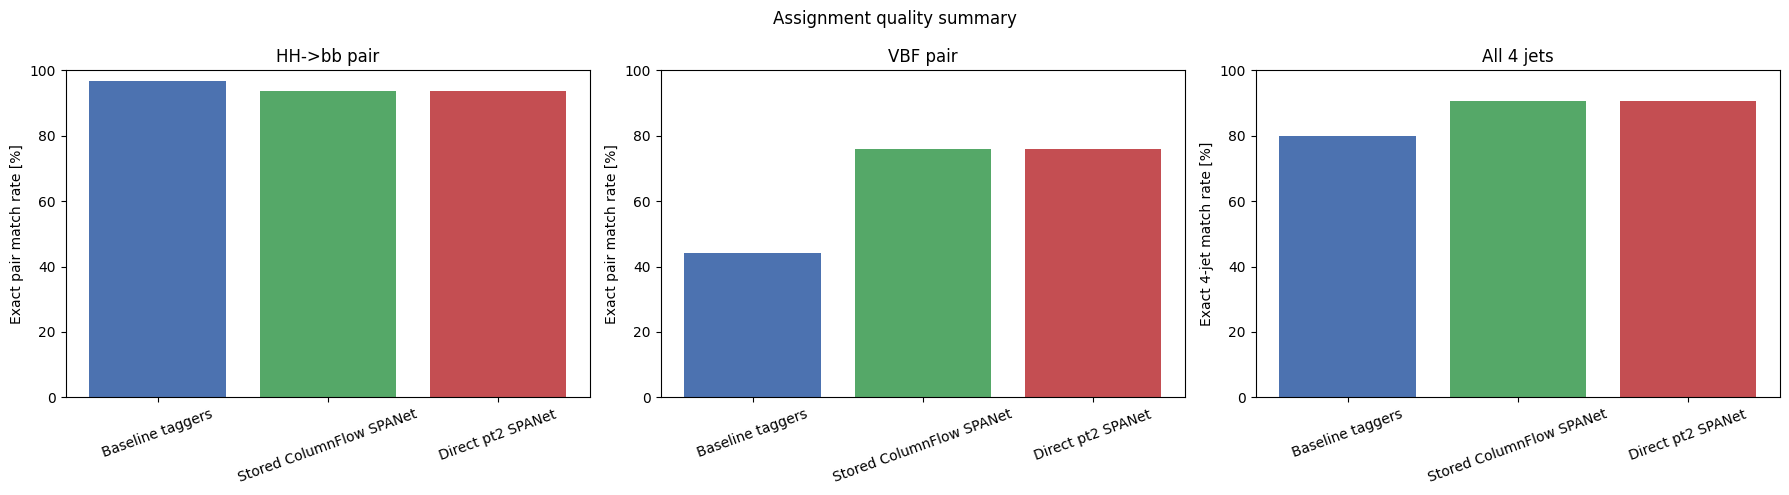

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pair_plot = target_summary[["Algorithm", "Target", "Exact pair match rate [%]"]].copy()
for ax, target in zip(axes[:2], [TARGET_LABELS["HHB"], TARGET_LABELS["VBF"]]):
    sub = pair_plot[pair_plot["Target"] == target]
    ax.bar(sub["Algorithm"], sub["Exact pair match rate [%]"], color=["#4C72B0", "#55A868", "#C44E52"])
    ax.set_title(target)
    ax.set_ylabel("Exact pair match rate [%]")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=20)

axes[2].bar(all4_summary["Algorithm"], all4_summary["All-4 exact match rate [%]"], color=["#4C72B0", "#55A868", "#C44E52"])
axes[2].set_title("All 4 jets")
axes[2].set_ylabel("Exact 4-jet match rate [%]")
axes[2].set_ylim(0, 100)
axes[2].tick_params(axis="x", rotation=20)

fig.suptitle("Assignment quality summary")
fig.tight_layout()
plt.show()

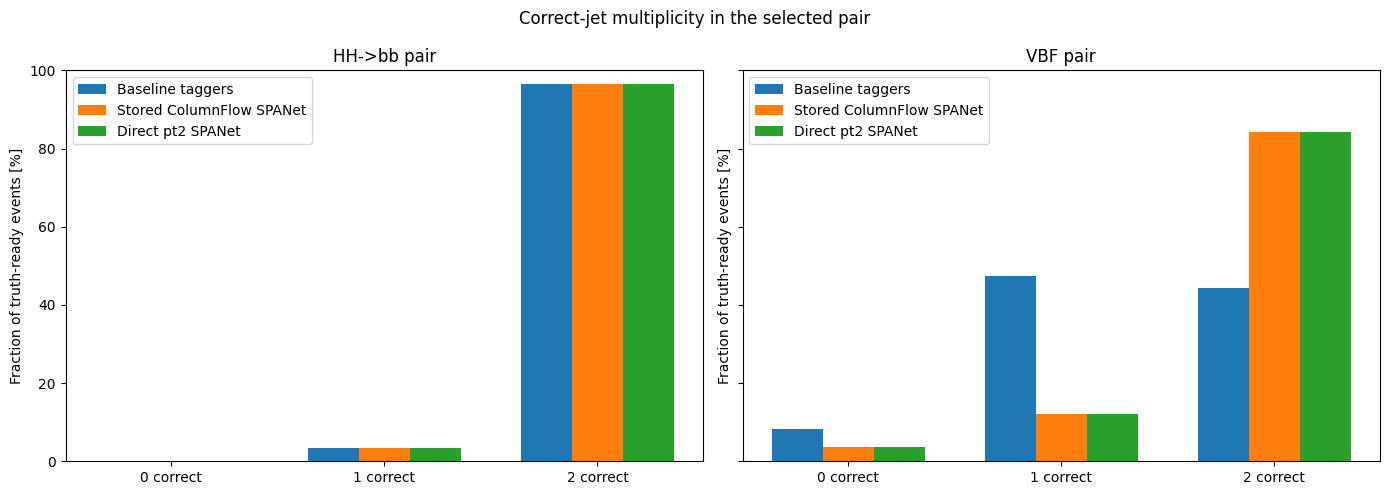

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, target in zip(axes, [TARGET_LABELS["HHB"], TARGET_LABELS["VBF"]]):
    sub = correct_jet_breakdown[correct_jet_breakdown["Target"] == target]
    algorithms = list(sub["Algorithm"].drop_duplicates())
    x = np.arange(3)
    width = 0.24
    for i, algorithm in enumerate(algorithms):
        vals = sub[sub["Algorithm"] == algorithm].sort_values("Correct jets in selected pair")["Fraction of truth-ready events [%]"].to_numpy()
        ax.bar(x + (i - 1) * width, vals, width=width, label=algorithm)
    ax.set_xticks(x)
    ax.set_xticklabels(["0 correct", "1 correct", "2 correct"])
    ax.set_title(target)
    ax.set_ylabel("Fraction of truth-ready events [%]")
    ax.set_ylim(0, 100)
    ax.legend()

fig.suptitle("Correct-jet multiplicity in the selected pair")
fig.tight_layout()
plt.show()

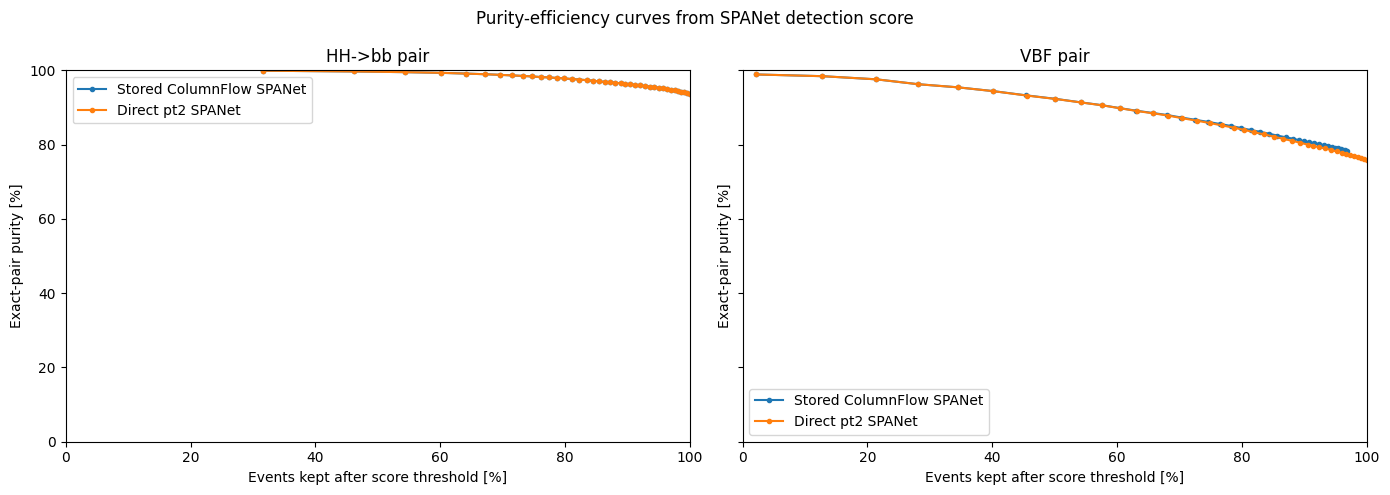

In [12]:
hhb_exact_stored = exact_pair_match(stored_hhb_seeds, truth_hhb_seeds) & truth_hhb_valid
hhb_exact_direct = exact_pair_match(direct_hhb_seeds, truth_hhb_seeds) & truth_hhb_valid
vbf_exact_stored = exact_pair_match(stored_vbf_seeds, truth_vbf_seeds) & truth_vbf_valid
vbf_exact_direct = exact_pair_match(direct_vbf_seeds, truth_vbf_seeds) & truth_vbf_valid

purity_curves = pd.concat([
    purity_vs_threshold(stored_hhb_detection[truth_hhb_valid], hhb_exact_stored[truth_hhb_valid], ALGO_LABELS["stored_cf_spanet"], TARGET_LABELS["HHB"]),
    purity_vs_threshold(direct_hhb_detection[truth_hhb_valid], hhb_exact_direct[truth_hhb_valid], ALGO_LABELS["direct_pt2_spanet"], TARGET_LABELS["HHB"]),
    purity_vs_threshold(stored_vbf_detection[truth_vbf_valid], vbf_exact_stored[truth_vbf_valid], ALGO_LABELS["stored_cf_spanet"], TARGET_LABELS["VBF"]),
    purity_vs_threshold(direct_vbf_detection[truth_vbf_valid], vbf_exact_direct[truth_vbf_valid], ALGO_LABELS["direct_pt2_spanet"], TARGET_LABELS["VBF"]),
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, target in zip(axes, [TARGET_LABELS["HHB"], TARGET_LABELS["VBF"]]):
    sub = purity_curves[purity_curves["target"] == target]
    for label in sub["label"].drop_duplicates():
        curve = sub[sub["label"] == label]
        ax.plot(curve["efficiency_pct"], curve["purity_pct"], marker="o", ms=3, label=label)
    ax.set_title(target)
    ax.set_xlabel("Events kept after score threshold [%]")
    ax.set_ylabel("Exact-pair purity [%]")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.legend()

fig.suptitle("Purity-efficiency curves from SPANet detection score")
fig.tight_layout()
plt.show()

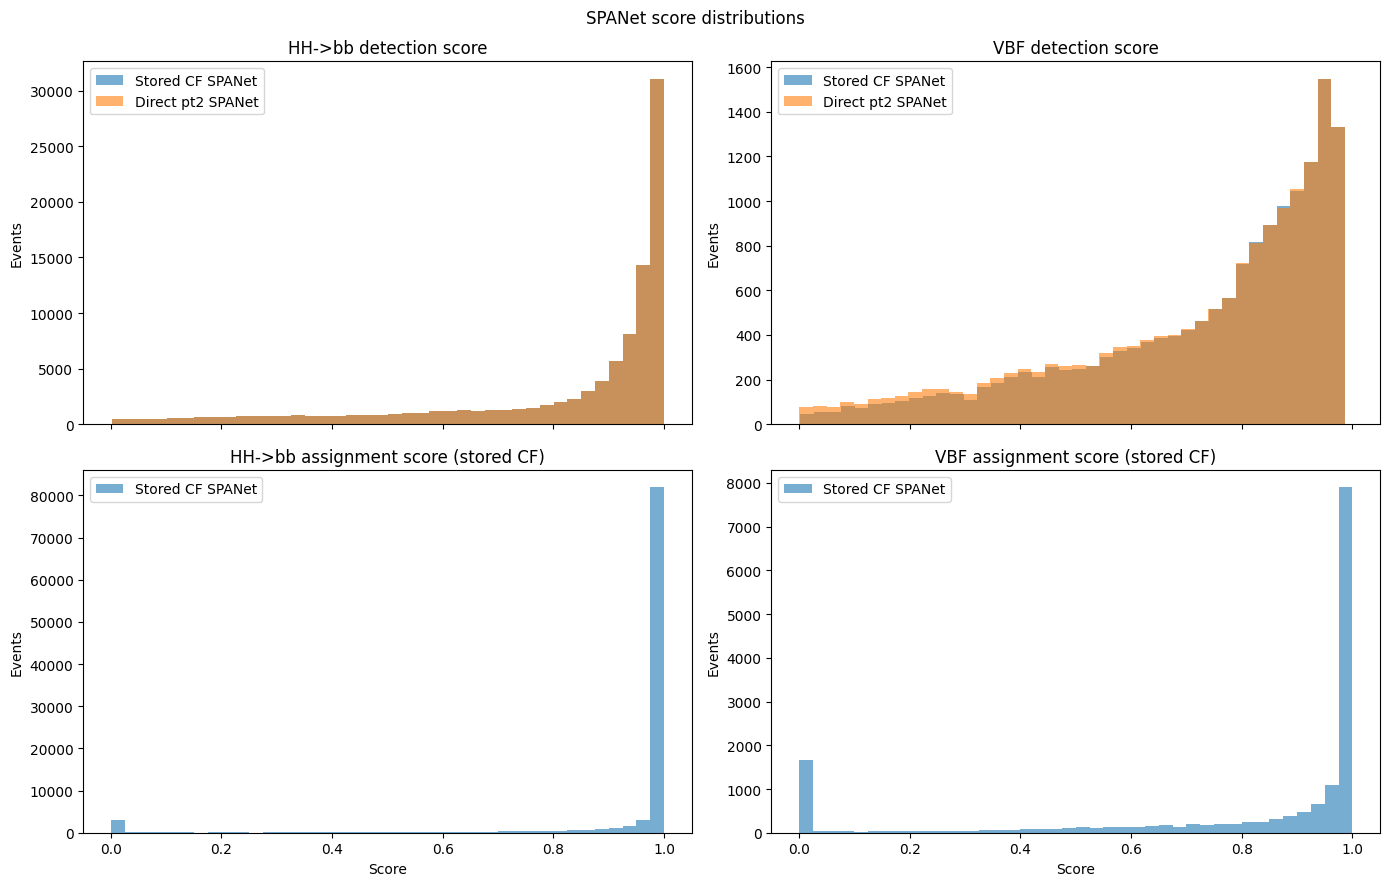

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex='col')

plot_specs = [
    (axes[0, 0], stored_hhb_detection[truth_hhb_valid], direct_hhb_detection[truth_hhb_valid], "HH->bb detection score"),
    (axes[0, 1], stored_vbf_detection[truth_vbf_valid], direct_vbf_detection[truth_vbf_valid], "VBF detection score"),
    (axes[1, 0], stored_hhb_assignment[truth_hhb_valid], target_summary.loc[(target_summary['Algorithm'] == ALGO_LABELS['stored_cf_spanet']) & (target_summary['Target'] == TARGET_LABELS['HHB'])].index.to_numpy(), ""),
    (axes[1, 1], stored_vbf_assignment[truth_vbf_valid], target_summary.loc[(target_summary['Algorithm'] == ALGO_LABELS['stored_cf_spanet']) & (target_summary['Target'] == TARGET_LABELS['VBF'])].index.to_numpy(), ""),
]

axes[0, 0].hist(stored_hhb_detection[truth_hhb_valid], bins=40, alpha=0.6, label='Stored CF SPANet')
axes[0, 0].hist(direct_hhb_detection[truth_hhb_valid], bins=40, alpha=0.6, label='Direct pt2 SPANet')
axes[0, 0].set_title('HH->bb detection score')
axes[0, 0].legend()

axes[0, 1].hist(stored_vbf_detection[truth_vbf_valid], bins=40, alpha=0.6, label='Stored CF SPANet')
axes[0, 1].hist(direct_vbf_detection[truth_vbf_valid], bins=40, alpha=0.6, label='Direct pt2 SPANet')
axes[0, 1].set_title('VBF detection score')
axes[0, 1].legend()

axes[1, 0].hist(stored_hhb_assignment[truth_hhb_valid], bins=40, alpha=0.6, label='Stored CF SPANet')
axes[1, 0].set_title('HH->bb assignment score (stored CF)')
axes[1, 0].set_xlabel('Score')
axes[1, 0].legend()

axes[1, 1].hist(stored_vbf_assignment[truth_vbf_valid], bins=40, alpha=0.6, label='Stored CF SPANet')
axes[1, 1].set_title('VBF assignment score (stored CF)')
axes[1, 1].set_xlabel('Score')
axes[1, 1].legend()

for ax in axes.flat:
    ax.set_ylabel('Events')

fig.suptitle('SPANet score distributions')
fig.tight_layout()
plt.show()